# 🍔 Junk Food Data Analysis & Visualization

### Exploratory Data Analysis using Python

**Tools:** Python • Pandas • Matplotlib • Seaborn • Jupyter Notebook

---

## 📌 Project Overview

This project explores a junk food dataset to identify patterns and relationships across **food types, brands, pricing, sales, popularity, and nutritional attributes**.

The analysis uses **data exploration, grouping, aggregation, and multiple visualization techniques** to understand the dataset and communicate insights visually.

### 📊 Visualizations Covered
- 📈 Line Plot
- 📊 Bar Plot
- 🔵 Scatter Plot
- 📉 Area Plot
- 📦 Box Plot
- 🥧 Pie Chart
- 🫧 Bubble Plot

> **Note:** This notebook focuses on exploratory data analysis and visualization. The dataset contains 1,000 records and 10 original features.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("junk_food_dataset (1).csv")
df

,Food_ID,JunkFood_Type,Brand,Price_USD,Country_Consumes,Annual_Sales_Units,Calories,Fat_g,Sugar_g,Popularity_Score
0,1,Ice Cream,McDonalds,7.48,India,241094,603,53.4,51.8,84
1,2,Fried Chicken,Pepsi,7.52,India,384413,299,7.7,19.6,68
2,3,Chocolate,Subway,11.28,Canada,464845,908,19.1,57.4,11
3,4,Hot Dog,Subway,1.71,Australia,347908,928,30.6,62.1,77
4,5,Ice Cream,Burger King,6.10,Japan,156956,1122,17.5,53.9,73
...,...,...,...,...,...,...,...,...,...,...
995,996,Soda,Dominos,13.20,Canada,309082,306,20.7,49.2,90
996,997,Soda,Coca-Cola,7.63,USA,447244,884,37.2,33.0,96
997,998,Chocolate,Burger King,12.59,Japan,64807,281,11.0,74.8,88
998,999,Pizza,KFC,8.99,USA,317021,1168,58.1,3.9,99


In [3]:
# Display first few records
df.head(30)

,Food_ID,JunkFood_Type,Brand,Price_USD,Country_Consumes,Annual_Sales_Units,Calories,Fat_g,Sugar_g,Popularity_Score
0,1,Ice Cream,McDonalds,7.48,India,241094,603,53.4,51.8,84
1,2,Fried Chicken,Pepsi,7.52,India,384413,299,7.7,19.6,68
2,3,Chocolate,Subway,11.28,Canada,464845,908,19.1,57.4,11
3,4,Hot Dog,Subway,1.71,Australia,347908,928,30.6,62.1,77
4,5,Ice Cream,Burger King,6.10,Japan,156956,1122,17.5,53.9,73
5,6,Soda,Pepsi,12.55,Brazil,161255,912,45.9,49.2,4
6,7,Fries,Burger King,9.64,Canada,479786,1151,55.6,71.4,76
7,8,Ice Cream,Pepsi,6.05,Germany,469462,225,28.3,6.3,73
8,9,Chocolate,Nestle,13.72,Japan,375180,748,23.8,26.5,77
9,10,Hot Dog,McDonalds,11.93,India,155331,374,57.9,19.9,48


In [4]:
df.describe()

,Food_ID,Price_USD,Annual_Sales_Units,Calories,Fat_g,Sugar_g,Popularity_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,8.137040,261982.465000,664.905000,32.574400,39.472500,51.912000
std,288.819436,3.918117,139682.223883,302.412691,15.788921,23.337133,28.565263
min,1.000000,1.500000,5336.000000,150.000000,5.100000,0.100000,1.000000
25%,250.750000,4.640000,146425.500000,401.500000,19.200000,19.100000,27.000000
50%,500.500000,8.110000,266874.000000,666.000000,31.950000,38.800000,54.000000
75%,750.250000,11.547500,383197.500000,930.250000,45.800000,60.925000,77.000000
max,1000.000000,15.000000,499955.000000,1199.000000,60.000000,80.000000,99.000000


In [5]:
df.shape

(1000, 10)

# 📊 Case Studies & Visualizations

The following case studies use different chart types to explore the junk food dataset from multiple perspectives.


## 1️⃣ Line Plot — Average Price by Popularity Score

In [7]:
#Line Plot: Trend of Average Price by Popularity Score

C:\Users\Pratik\AppData\Local\Temp\ipykernel_1036\3069631150.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_trend = df.groupby('Popularity_Group')['Price_USD'].mean().reset_index()


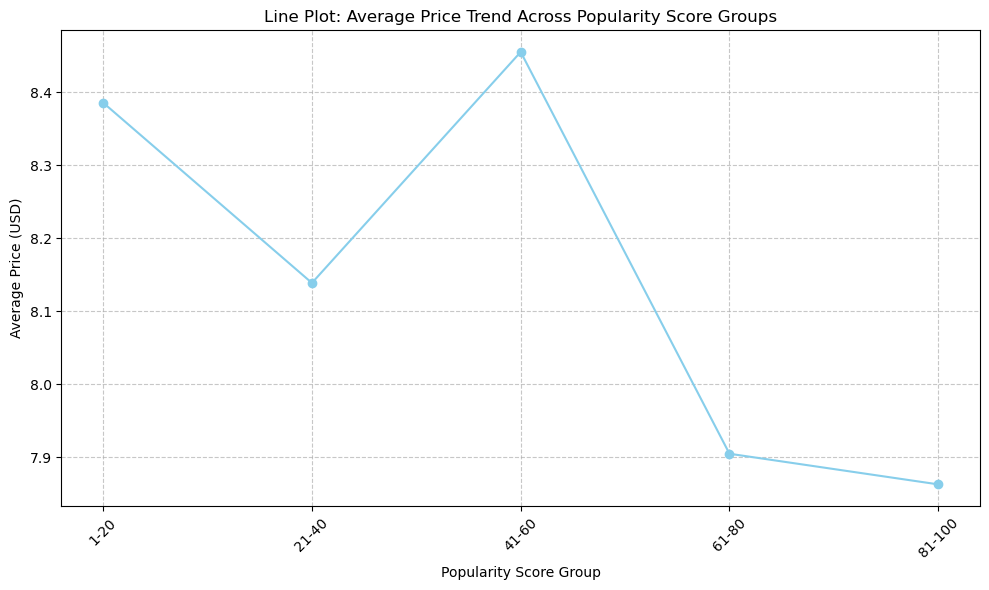

In [8]:
# Create Popularity Score bins (e.g., 0-20, 21-40, ...)
bins = list(range(0, 101, 20))
labels = [f'{i+1}-{i+20}' for i in bins[:-1]]
df['Popularity_Group'] = pd.cut(df['Popularity_Score'], bins=bins, labels=labels, right=True, include_lowest=True)

# Calculate the average price for each popularity group
price_trend = df.groupby('Popularity_Group')['Price_USD'].mean().reset_index()

# Plotting the Line Plot
plt.figure(figsize=(10, 6))
plt.plot(price_trend['Popularity_Group'], price_trend['Price_USD'], marker='o', linestyle='-', color='skyblue')
plt.title('Line Plot: Average Price Trend Across Popularity Score Groups')
plt.xlabel('Popularity Score Group')
plt.ylabel('Average Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2️⃣ Bar Plot — Total Annual Sales by Junk Food Type

In [9]:
#Bar Plot: Total Annual Sales by Junk Food Type

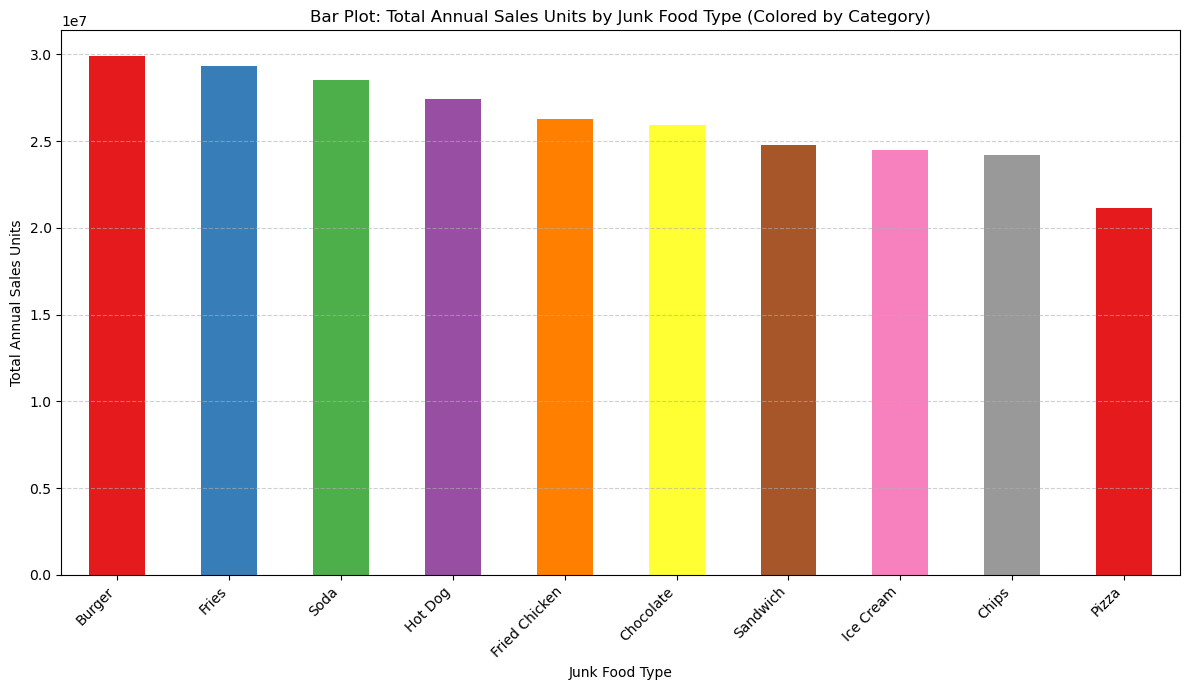

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load the dataset
df = pd.read_csv("junk_food_dataset (1).csv")

# 1. Calculate total sales for each food type and sort (as before)
sales_by_type = df.groupby('JunkFood_Type')['Annual_Sales_Units'].sum().sort_values(ascending=False)

# 2. Define colors for each bar using a colormap
# There are 7 unique food types, so we use 7 distinct colors from the 'Set1' map.
num_bars = len(sales_by_type)
colors = cm.Set1.colors[:num_bars]

# 3. Plotting the Bar Plot with unique colors
plt.figure(figsize=(12, 7))
# Pass the list of colors to the 'color' parameter
sales_by_type.plot(kind='bar', color=colors)
plt.title('Bar Plot: Total Annual Sales Units by Junk Food Type (Colored by Category)')
plt.xlabel('Junk Food Type')
plt.ylabel('Total Annual Sales Units')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3️⃣ Scatter Plot — Fat vs. Calories

In [11]:
#Scatter Plot: Fat vs. Calories, Colored by Brand

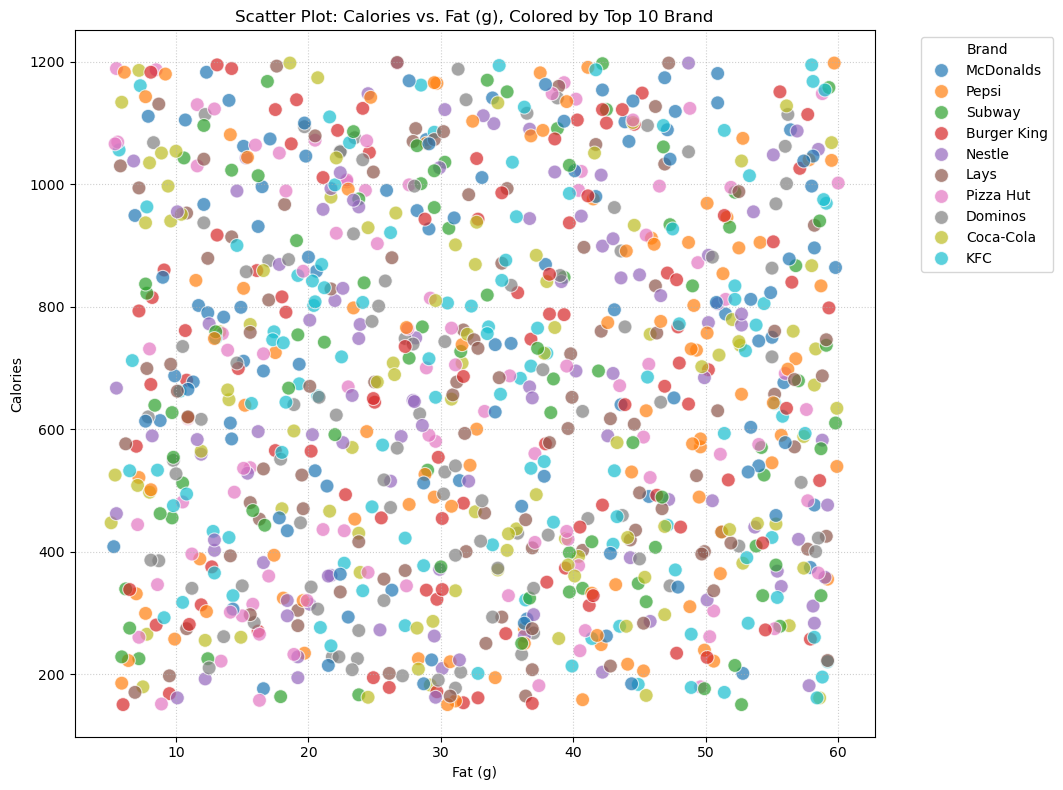

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Used for better color handling

# Load the dataset
df = pd.read_csv("junk_food_dataset (1).csv")

# Reduce number of brands for clearer visualization, focusing on the top 10
top_brands = df['Brand'].value_counts().nlargest(10).index
df_filtered = df[df['Brand'].isin(top_brands)]

# Plotting the Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Fat_g', y='Calories', hue='Brand', data=df_filtered, s=100, alpha=0.7)
plt.title('Scatter Plot: Calories vs. Fat (g), Colored by Top 10 Brand')
plt.xlabel('Fat (g)')
plt.ylabel('Calories')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(rect=(0, 0, 0.9, 1))
plt.show()

## 4️⃣ Area Plot — Cumulative Sugar

In [13]:
#Area Plot: Cumulative Sugar (g) Over Food ID (Proxy for Order)

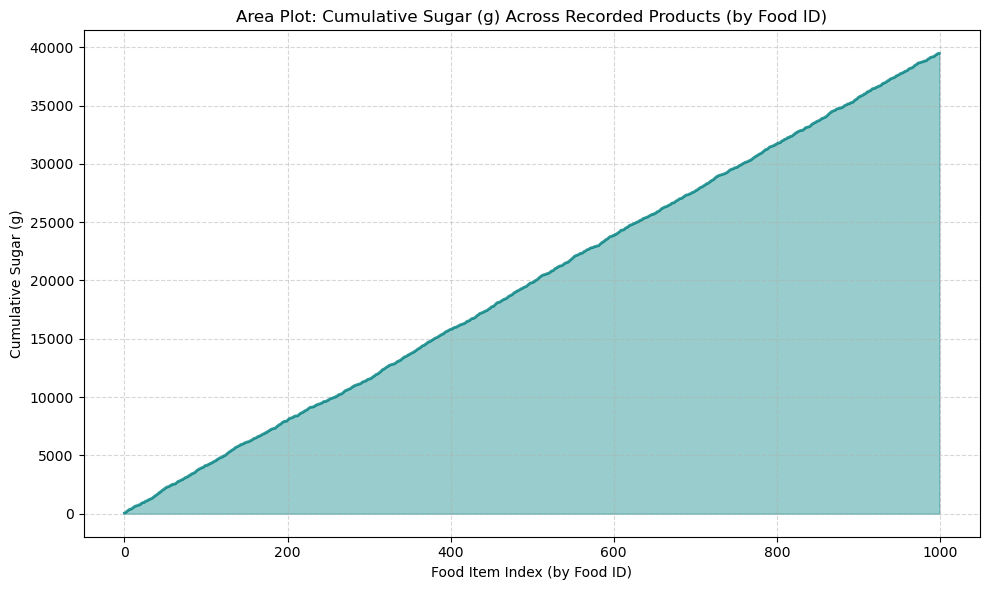

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("junk_food_dataset (1).csv")

# Sort by Food_ID (which is already sorted) and calculate the cumulative sum of Sugar_g
df_cumulative = df.sort_values(by='Food_ID')['Sugar_g'].cumsum().reset_index(drop=True)

# Plotting the Area Plot
plt.figure(figsize=(10, 6))
plt.fill_between(df_cumulative.index, df_cumulative.values, color="teal", alpha=0.4)
plt.plot(df_cumulative.index, df_cumulative.values, color="teal", alpha=0.8, linewidth=2)
plt.title('Area Plot: Cumulative Sugar (g) Across Recorded Products (by Food ID)')
plt.xlabel('Food Item Index (by Food ID)')
plt.ylabel('Cumulative Sugar (g)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5️⃣ Box Plot — Price Distribution by Country

In [15]:
#Box Plot: Distribution of Price (USD) by Country

C:\Users\Pratik\AppData\Local\Temp\ipykernel_1036\1151890229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country_Consumes', y='Price_USD', data=df_filtered, palette='Set3')


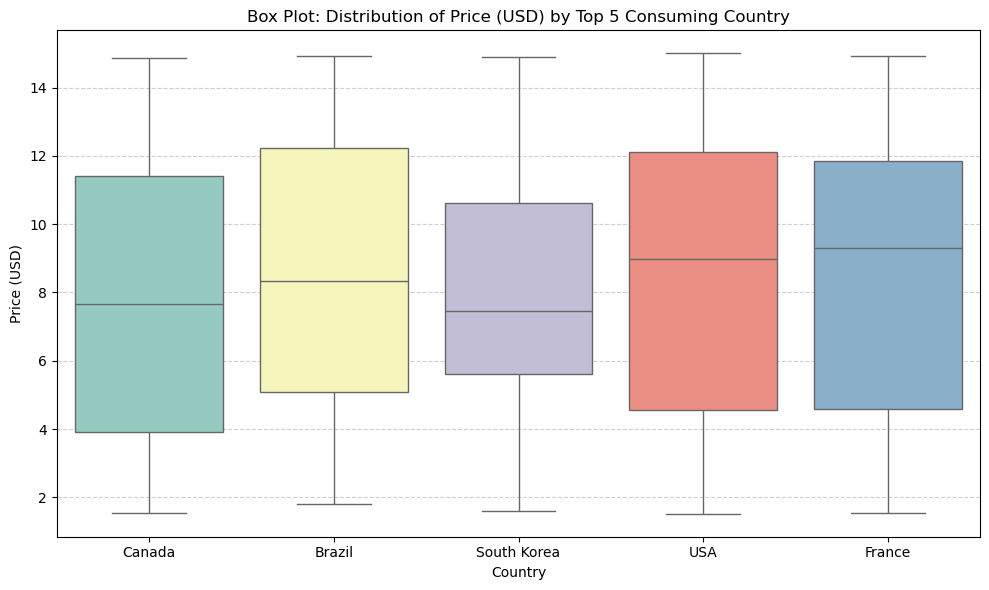

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("junk_food_dataset (1).csv")

# Filter for the top 5 consuming countries for a cleaner plot
top_countries = df['Country_Consumes'].value_counts().nlargest(5).index
df_filtered = df[df['Country_Consumes'].isin(top_countries)]

# Plotting the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country_Consumes', y='Price_USD', data=df_filtered, palette='Set3')
plt.title('Box Plot: Distribution of Price (USD) by Top 5 Consuming Country')
plt.xlabel('Country')
plt.ylabel('Price (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 6️⃣ Pie Chart — Market Share by Top 5 Brands

In [17]:
#Pie Chart: Market Share of Total Annual Sales by Top 5 Brands

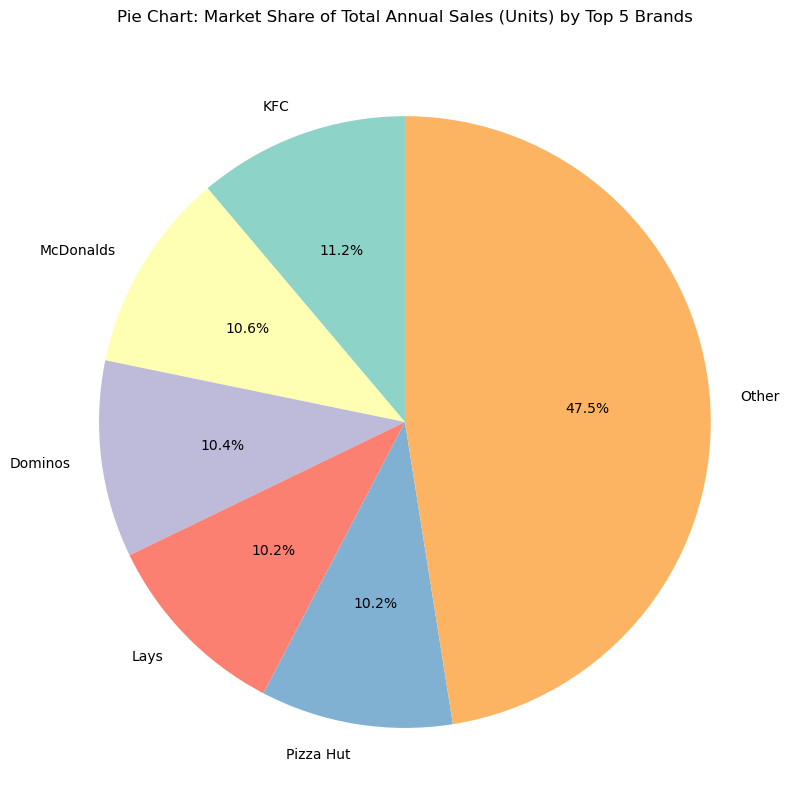

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("junk_food_dataset (1).csv")

# Calculate total sales for each brand and select the top 5
sales_by_brand = df.groupby('Brand')['Annual_Sales_Units'].sum().sort_values(ascending=False)
top_5_brands = sales_by_brand.nlargest(5)

# Combine the remaining brands into an "Other" category
other_sales = sales_by_brand.iloc[5:].sum()

# FIX: Use pd.concat() to combine the two series
pie_data = pd.concat([top_5_brands, pd.Series(other_sales, index=['Other'])])

# Plotting the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Pie Chart: Market Share of Total Annual Sales (Units) by Top 5 Brands', y=1.05)
plt.axis('equal') # Ensures the pie chart is circular
plt.tight_layout()
plt.show()

## 7️⃣ Bubble Plot — Price, Calories & Popularity by Food Type

In [19]:
#Bubble Plot: Price, Calories, and Popularity by Junk Food Type#

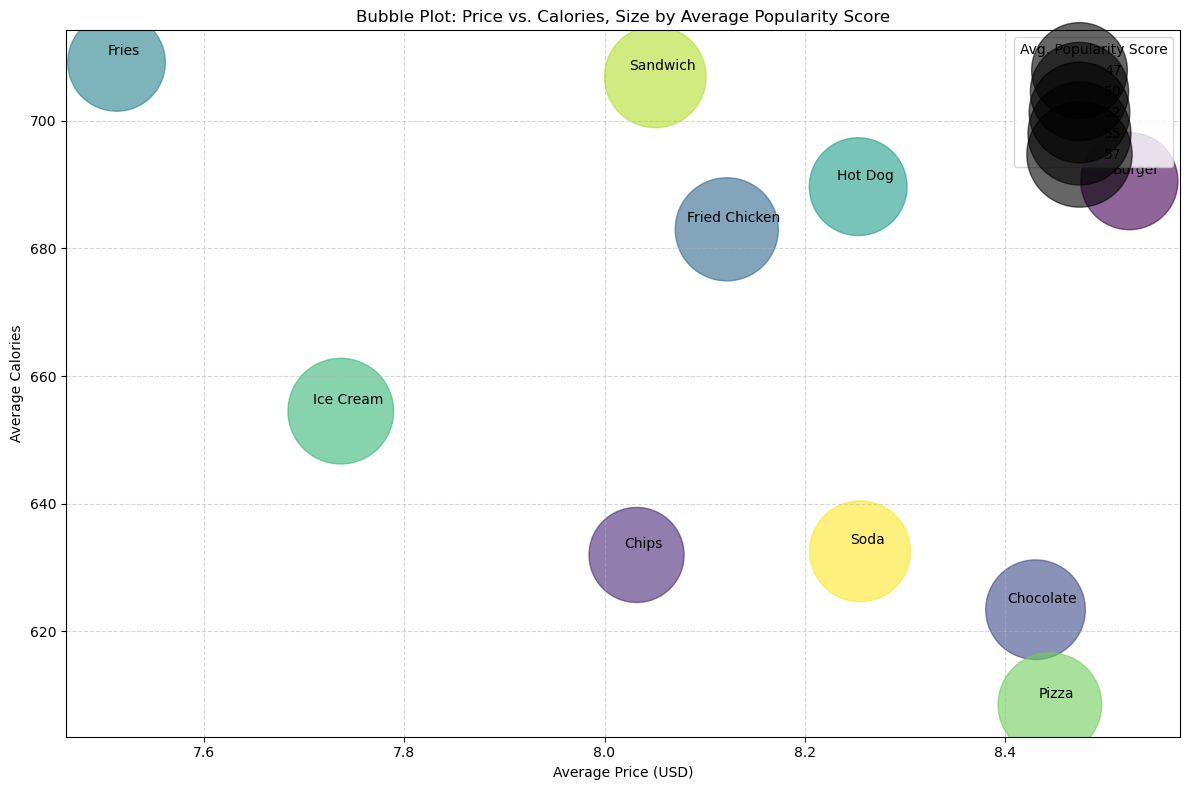

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("junk_food_dataset (1).csv")

# Calculate the mean of Price, Calories, and Popularity for each food type
bubble_data = df.groupby('JunkFood_Type').agg({
    'Price_USD': 'mean',
    'Calories': 'mean',
    'Popularity_Score': 'mean'
}).reset_index()

# Scale the Popularity Score for bubble size (adjust multiplier for visual effect)
bubble_data['Size'] = bubble_data['Popularity_Score'] * 100

# Plotting the Bubble Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    x=bubble_data['Price_USD'],
    y=bubble_data['Calories'],
    s=bubble_data['Size'], # Bubble size is scaled Popularity Score
    alpha=0.6,
    c=bubble_data.index, # Color by index (JunkFood_Type)
    cmap='viridis'
)

# Add labels for each bubble (Junk Food Type)
for i, row in bubble_data.iterrows():
    plt.annotate(row['JunkFood_Type'], (row['Price_USD'], row['Calories']),
                 textcoords="offset points", xytext=(5,5), ha='center')

plt.title('Bubble Plot: Price vs. Calories, Size by Average Popularity Score')
plt.xlabel('Average Price (USD)')
plt.ylabel('Average Calories')

# Create a proxy legend for size
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6, num=5)

# FIX: Clean the LaTeX formatting from the labels before conversion
cleaned_labels = [label.replace("$", "").replace("\\mathdefault{", "").replace("}", "") for label in labels]
# Recalculate the legend labels based on the cleaned strings
legend_labels = [f'{int(float(cleaned_label)/100)}' for cleaned_label in cleaned_labels] 

plt.legend(handles, legend_labels, title="Avg. Popularity Score", loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

# ✅ Conclusion

This project demonstrates a practical workflow for **exploratory data analysis and data visualization** using Python. By combining descriptive statistics with different chart types, the analysis provides a visual understanding of **sales, pricing, popularity, brands, food categories, and nutritional attributes**.

### 🛠️ Skills Demonstrated
- Data exploration with Pandas
- Descriptive statistics
- Grouping and aggregation
- Data filtering
- Data visualization
- Pattern identification
- Analytical storytelling

**Project completed using Python and Jupyter Notebook.**
